<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/VAE_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upload kaggle.json before running this step
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d jessicali9530/celeba-dataset -f img_align_celeba.zip
!unzip -q img_align_celeba.zip -d celeba_data

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset
unzip:  cannot find or open img_align_celeba.zip, img_align_celeba.zip.zip or img_align_celeba.zip.ZIP.


In [ ]:
from google.colab import files
import os

# 1. Setup Kaggle credentials
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        !mkdir -p ~/.kaggle
        !mv kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json

# 2. Download and initial unzip
if not os.path.exists('celeba-dataset.zip'):
    !kaggle datasets download -d jessicali9530/celeba-dataset

if not os.path.exists('celeba_data'):
    !unzip -q celeba-dataset.zip -d celeba_data

# 3. Extract the actual images
# Keras image_dataset_from_directory looks for images in subfolders.
if os.path.exists('celeba_data/img_align_celeba.zip'):
    print("Extracting images... this may take a minute.")
    !unzip -q celeba_data/img_align_celeba.zip -d celeba_data/
    print("Extraction complete.")

In [ ]:
print('Checking for img_align_celeba.zip:')
!ls -l img_align_celeba.zip

Checking for img_align_celeba.zip:
ls: cannot access 'img_align_celeba.zip': No such file or directory


In [ ]:
print('\nChecking contents of celeba_data directory:')
!ls -l celeba_data


Checking contents of celeba_data directory:
ls: cannot access 'celeba_data': No such file or directory


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import os

# Adjusting path to where images are usually extracted
data_path = "celeba_data/img_align_celeba"

# Load and scale images to [0, 1]
dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    label_mode=None,
    image_size=(64, 64),
    batch_size=64
).map(lambda x: x / 255.0)

print("Dataset loaded successfully.")

Found 202599 files.
Dataset loaded successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Load and scale images to [0, 1] in one shot
dataset = tf.keras.utils.image_dataset_from_directory(
    "celeba_data", label_mode=None, image_size=(64, 64), batch_size=64
).map(lambda x: x / 255.0)

Found 202599 files.


In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon # z = mu + sigma * epsilon

In [ ]:
LATENT_DIM = 256

encoder_inputs = layers.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# Distribution parameters
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [ ]:
decoder_inputs = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(16 * 16 * 64, activation="relu")(decoder_inputs)
x = layers.Reshape((16, 16, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = Model(decoder_inputs, decoder_outputs, name="decoder")

In [ ]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # 1. Reconstruction Loss (MSE) - Fixed attribute name to .mse
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(data, reconstruction), axis=(1, 2)))

            # 2. KL Divergence Regularization Loss
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(dataset.take(100), epochs=5) # Kept small for fast classroom execution

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - kl_loss: 0.0993 - loss: 332.4184 - recon_loss: 332.3192
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - kl_loss: 0.1469 - loss: 346.2178 - recon_loss: 346.0709
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - kl_loss: 0.1763 - loss: 326.9554 - recon_loss: 326.7791
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - kl_loss: 0.1595 - loss: 332.0586 - recon_loss: 331.8991
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - kl_loss: 0.1364 - loss: 329.2051 - recon_loss: 329.0687


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


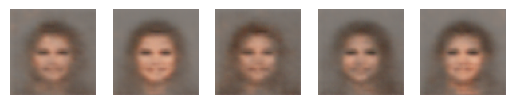

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample standard random values from our Latent Space manifold
random_latent = np.random.normal(size=(5, LATENT_DIM))
generated_images = vae.decoder.predict(random_latent)

# Plot generated outputs
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


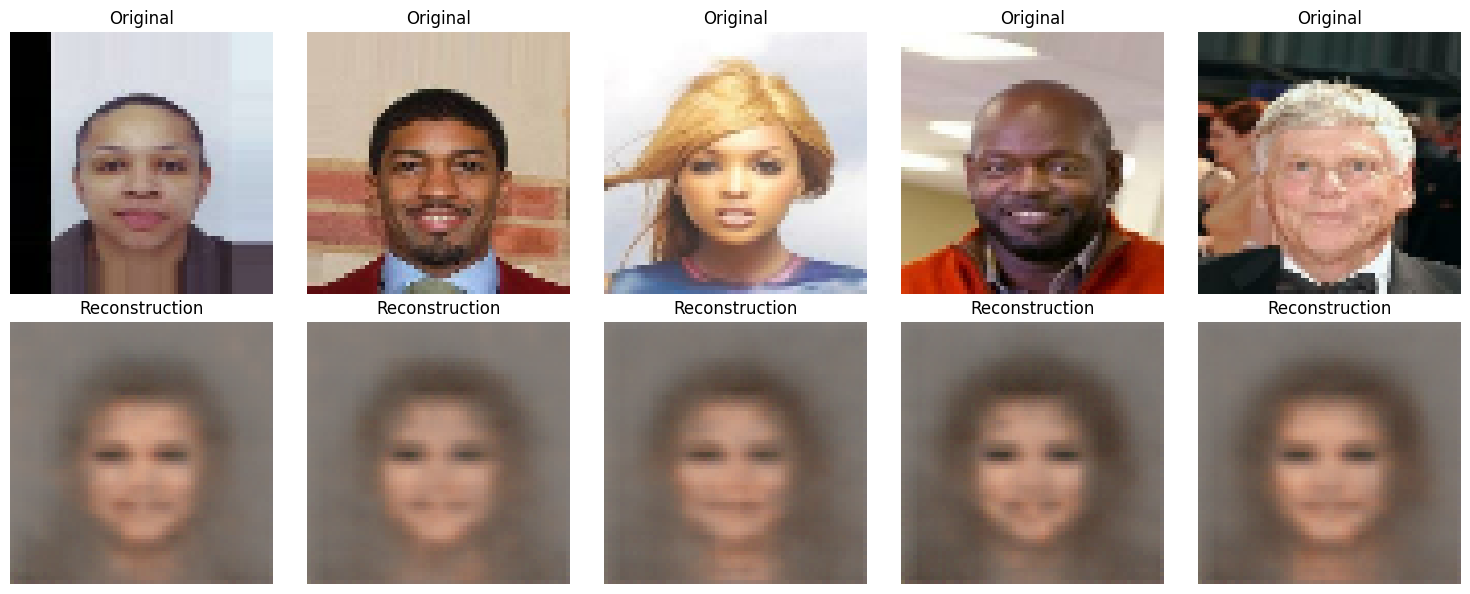

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


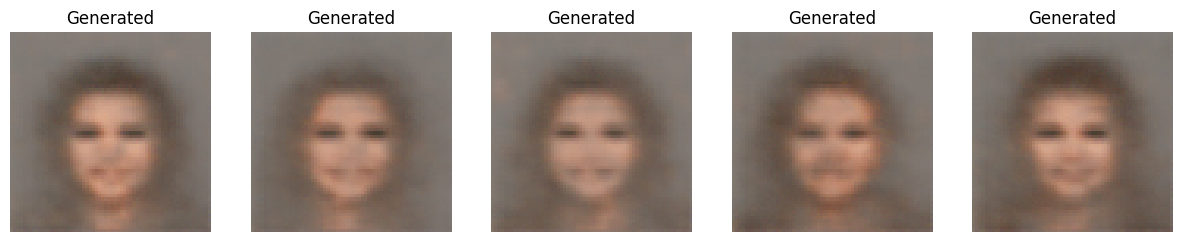

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get a batch of original images
images = next(iter(dataset.take(1)))

# 2. Pass them through the VAE
z_mean, z_log_var, z = encoder.predict(images)
reconstructions = decoder.predict(z)

# 3. Plot Original vs Reconstruction
plt.figure(figsize=(15, 6))
for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructions[i])
    plt.title("Reconstruction")
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Generate entirely new faces
random_latent_vectors = tf.random.normal(shape=(5, LATENT_DIM))
generated_faces = decoder.predict(random_latent_vectors)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_faces[i])
    plt.title("Generated")
    plt.axis("off")
plt.show()